# ResNet1D on raw EMG waveforms: training

Trains Wang et al. 2017's ResNet (`resnet1d.py`) on per-trial z-scored raw EMG (`loadData.py`) for Subject 2.
Settings and their sources are in `../../PLAN.md` (Step 3). Run from inside `training_runs/subject_02/`.

**How to use:** run the Setup, Training functions and Graphing sections once. Then each of sections 1–4 trains one
model type and graphs it, and can be run on its own. Everything a run produces goes to `results/`:
`results.json` (rewritten after each section, so
sections from earlier sessions are kept; **Overall statistics** at the end summarizes everything saved so far),
`progress.log` (appended to; `tail -f results/progress.log` to follow it), and one trained model per run.

## Setup

In [1]:
import json, os, sys, time, warnings

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")  # resnet1d/, for loadData.py and resnet1d.py
from loadData import loadZscoredTrainTestSplit
from resnet1d import resnet1dNet

# PyTorch warns that padding = "same" with the even kernel of 8 makes an internal padded copy; results are unaffected.
warnings.filterwarnings("ignore", message = "Using padding='same' with even kernel lengths")

In [2]:
subjectNumber = 2
numberSeeds = 5
numberEpochs = 300
batchSize = 32
device = torch.device("cuda:0")

print(torch.cuda.get_device_name(0), torch.__version__)

NVIDIA GeForce RTX 3090 2.14.0+cu130


In [3]:
def report(line):
    print(line)
    with open("results/progress.log", "a") as logFile:
        logFile.write(line + "\n")


# Results saved by earlier sessions are loaded, so any section can be (re)run on its own without losing the others.
results = json.load(open("results/results.json")) if os.path.exists("results/results.json") else {}
print("configs already in results.json:", list(results) or "none")

configs already in results.json: none


## Training functions

- `loadTrialsOntoGpu`: loads one recording with `loadData.py` (per-trial z-scoring, fixed 6/4 split) and moves it to the GPU.
- `evaluate`: test loss and accuracy, in eval mode, without gradients.
- `trainOneRun`: trains one fresh model for `numberEpochs` and returns its per-epoch history, plus a copy of the weights
  from the epoch with the highest test accuracy.
- `trainAllSeeds`: runs `trainOneRun` for every seed, reads the three test accuracies off each history, saves each run's
  model to `results/<config>_seed<N>_bestTestAccuracy.pt`, and saves everything else to `results/results.json`.

In [4]:
def loadTrialsOntoGpu(taskFolder, articulationManner):
    """taskFolder is "Phoneme" or "Words"; articulationManner is "Voiced" or "Unvoiced"."""
    trainTrials, trainLabels, testTrials, testLabels = loadZscoredTrainTestSplit(taskFolder, articulationManner, subjectNumber)
    print(f"Subject {subjectNumber} {taskFolder} {articulationManner}: train {trainTrials.shape}, test {testTrials.shape}")
    return [torch.from_numpy(array).to(device) for array in (trainTrials, trainLabels, testTrials, testLabels)]

In [5]:
def evaluate(model, trials, labels, lossFunction):
    """Mean loss and accuracy in eval mode (BatchNorm uses its running statistics, so trials don't affect each other)."""
    model.eval()
    lossSum, correctCount = 0.0, 0

    with torch.no_grad():
        for start in range(0, len(labels), batchSize):
            scores = model(trials[start:start + batchSize])
            batchLabels = labels[start:start + batchSize]

            lossSum += lossFunction(scores, batchLabels).item() * len(batchLabels)
            correctCount += (scores.argmax(dim = 1) == batchLabels).sum().item()

    return lossSum / len(labels), correctCount / len(labels)

In [6]:
def trainOneRun(trainTrials, trainLabels, testTrials, testLabels, seed):
    torch.manual_seed(seed)
    model = resnet1dNet(numberClasses = int(trainLabels.max()) + 1).to(device)
    lossFunction = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, betas = (0.9, 0.999), eps = 1e-8)
    # From Wang et al.'s code: halve the learning rate when training loss hasn't improved for 50 epochs, down to 1e-4.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 50, min_lr = 1e-4)

    history = {"trainLoss": [], "trainAccuracy": [], "testLoss": [], "testAccuracy": [], "learningRate": []}
    # Weights from the epoch with the highest test accuracy (first one on ties, like np.argmax), copied to the CPU.
    bestTestAccuracy, bestTestAccuracyWeights = -1, None

    report(" epoch  train loss  train acc  test loss  test acc       lr  s/epoch")
    startTime = time.time()
    for epoch in range(numberEpochs):
        model.train() # Set to train mode
        shuffledOrder = torch.randperm(len(trainLabels), device = device)
        lossSum, correctCount = 0.0, 0

        for start in range(0, len(shuffledOrder), batchSize):
            batchIndices = shuffledOrder[start:start + batchSize]
            scores = model(trainTrials[batchIndices]) # Gets inference scores in the suffled order
            loss = lossFunction(scores, trainLabels[batchIndices])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lossSum += loss.item() * len(batchIndices)
            correctCount += (scores.argmax(dim = 1) == trainLabels[batchIndices]).sum().item()

        # Training loss = average over this epoch's batches in train mode, like the Keras "loss" Wang's rule selects on.
        epochMetrics = {"trainLoss": lossSum / len(trainLabels),
                        "trainAccuracy": correctCount / len(trainLabels),
                        "learningRate": optimizer.param_groups[0]["lr"]}
        scheduler.step(epochMetrics["trainLoss"])
        epochMetrics["testLoss"], epochMetrics["testAccuracy"] = evaluate(model, testTrials, testLabels, lossFunction)

        for key, value in epochMetrics.items():
            history[key].append(value)

        if epochMetrics["testAccuracy"] > bestTestAccuracy:
            bestTestAccuracy = epochMetrics["testAccuracy"]
            bestTestAccuracyWeights = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        # Print out status every 10 epochs
        if (epoch + 1) % 10 == 0:
            m = epochMetrics
            report(f"{epoch + 1:>6}  {m['trainLoss']:>10.4f}  {m['trainAccuracy']:>9.3f}  {m['testLoss']:>9.4f}  {m['testAccuracy']:>8.3f}"
                   f"  {m['learningRate']:>7.1e}  {(time.time() - startTime) / (epoch + 1):>7.2f}")

    return history, bestTestAccuracyWeights

In [7]:
# The three ways of turning a run's per-epoch test accuracies into one number (see PLAN.md, Step 3).
accuracyRuleLabels = {"testAccuracyAtLowestTrainLoss": "at lowest train loss (ours)",
                      "bestTestAccuracy": "best across epochs (ours)",
                      "finalTestAccuracy": "final epoch"}


def trainAllSeeds(configName, trainTrials, trainLabels, testTrials, testLabels):
    runs = []
    for seed in range(numberSeeds):
        report(f"=== {configName}, seed {seed}")

        history, bestTestAccuracyWeights = trainOneRun(trainTrials, trainLabels, testTrials, testLabels, seed)

        modelPath = f"results/{configName}_seed{seed}_bestTestAccuracy.pt"
        torch.save(bestTestAccuracyWeights, modelPath)

        lowestTrainLossEpoch = int(np.argmin(history["trainLoss"]))
        bestTestEpoch = int(np.argmax(history["testAccuracy"]))
        run = {"seed": seed,
               "testAccuracyAtLowestTrainLoss": history["testAccuracy"][lowestTrainLossEpoch],
               "lowestTrainLossEpoch": lowestTrainLossEpoch + 1,
               "bestTestAccuracy": history["testAccuracy"][bestTestEpoch],
               "bestTestAccuracyEpoch": bestTestEpoch + 1,
               "finalTestAccuracy": history["testAccuracy"][-1],
               "modelPath": modelPath,
               "history": history}

        report(f"test accuracy, {configName} seed {seed}:")
        report(f"  {accuracyRuleLabels['testAccuracyAtLowestTrainLoss']:<28} {run['testAccuracyAtLowestTrainLoss']:.3f}  (epoch {run['lowestTrainLossEpoch']})")
        report(f"  {accuracyRuleLabels['bestTestAccuracy']:<28} {run['bestTestAccuracy']:.3f}  (epoch {run['bestTestAccuracyEpoch']})")
        report(f"  {accuracyRuleLabels['finalTestAccuracy']:<28} {run['finalTestAccuracy']:.3f}")
        report(f"  saved model from epoch {run['bestTestAccuracyEpoch']} to {modelPath}")
        runs.append(run)

    results[configName] = {"numberClasses": int(trainLabels.max()) + 1,
                           "numberTestTrials": len(testLabels),
                           "numberEpochs": numberEpochs,
                           "batchSize": batchSize,
                           "numberSeeds": numberSeeds,
                           "runs": runs}
    with open("results/results.json", "w") as resultsFile:
        json.dump(results, resultsFile)

## Graphing function

`plotTrainingCurves` draws one config's train/test accuracy and training loss over epochs
(mean over seeds, shaded min–max when there is more than one seed). It reads from `results`, so it also works for configs saved to `results/results.json` in an earlier session.

In [8]:
def plotTrainingCurves(configName):
    config = results[configName]
    epochNumbers = np.arange(1, config["numberEpochs"] + 1)
    fig, (accuracyAxis, lossAxis) = plt.subplots(1, 2, figsize = (12, 3.5))

    # Left: train and test accuracy
    for key, label in [("trainAccuracy", "train"), ("testAccuracy", "test")]:
        valuesBySeed = np.array([run["history"][key] for run in config["runs"]])
        accuracyAxis.plot(epochNumbers, valuesBySeed.mean(0), label = label)
        accuracyAxis.fill_between(epochNumbers, valuesBySeed.min(0), valuesBySeed.max(0), alpha = 0.2)
    accuracyAxis.axhline(1 / config["numberClasses"], color = "gray", ls = ":", lw = 1, label = "chance")
    accuracyAxis.set(title = configName + ": accuracy", xlabel = "epoch", ylabel = "accuracy")
    accuracyAxis.legend(fontsize = 8)

    # Right: training loss, log scale
    trainLossBySeed = np.array([run["history"]["trainLoss"] for run in config["runs"]])
    lossAxis.semilogy(epochNumbers, trainLossBySeed.mean(0))
    lossAxis.set(title = configName + ": training loss", xlabel = "epoch", ylabel = "train loss (log)")

    plt.tight_layout()
    plt.show()

## 1. All phonemes, voiced

In [9]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Phoneme", "Voiced")
trainAllSeeds("allPhonemes_Voiced", trainTrials, trainLabels, testTrials, testLabels)

Subject 2 Phoneme Voiced: train (228, 22, 7500), test (152, 22, 7500)
=== allPhonemes_Voiced, seed 0


 epoch  train loss  train acc  test loss  test acc       lr  s/epoch


    10      2.2872      0.342     2.2548     0.270  1.0e-03     0.61


    20      1.7195      0.496     1.8887     0.329  1.0e-03     0.61


    30      1.4586      0.557     1.7638     0.408  1.0e-03     0.61


...

   260      0.1509      0.982     1.2085     0.553  1.0e-03     0.59


   270      0.1329      0.991     1.5195     0.539  1.0e-03     0.59


   280      0.1704      0.974     1.8494     0.513  1.0e-03     0.59


   290      0.1566      0.978     1.7534     0.526  1.0e-03     0.59


   300      0.2388      0.943     2.1569     0.487  1.0e-03     0.59
test accuracy, allPhonemes_Voiced seed 4:
  at lowest train loss (ours)  0.586  (epoch 251)
  best across epochs (ours)    0.704  (epoch 294)
  final epoch                  0.487
  saved model from epoch 294 to results/allPhonemes_Voiced_seed4_bestTestAccuracy.pt


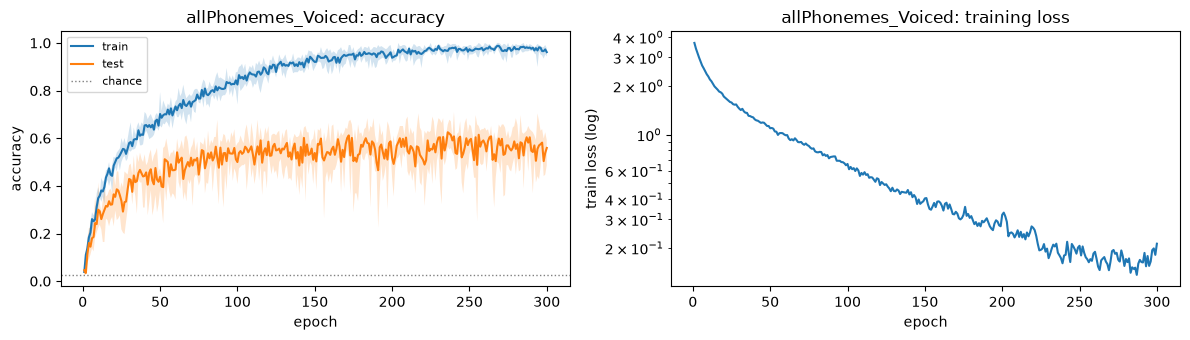

In [10]:
plotTrainingCurves("allPhonemes_Voiced")

## 2. All phonemes, unvoiced

In [11]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Phoneme", "Unvoiced")
trainAllSeeds("allPhonemes_Unvoiced", trainTrials, trainLabels, testTrials, testLabels)

Subject 2 Phoneme Unvoiced: train (228, 22, 7500), test (152, 22, 7500)
=== allPhonemes_Unvoiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch


    10      2.2051      0.404     2.1822     0.336  1.0e-03     0.59


    20      1.6765      0.535     1.7961     0.414  1.0e-03     0.59


    30      1.2878      0.658     1.9616     0.349  1.0e-03     0.59


    40      1.0725      0.737     1.6515     0.428  1.0e-03     0.59


...

   260      0.2013      0.965     1.4039     0.553  1.0e-03     0.59


   270      0.2041      0.969     1.6155     0.480  1.0e-03     0.59


   280      0.2133      0.943     2.0023     0.467  1.0e-03     0.59


   290      0.1902      0.969     1.9383     0.441  1.0e-03     0.59


   300      0.1574      0.974     1.3959     0.559  1.0e-03     0.59
test accuracy, allPhonemes_Unvoiced seed 4:
  at lowest train loss (ours)  0.572  (epoch 287)
  best across epochs (ours)    0.645  (epoch 114)
  final epoch                  0.559
  saved model from epoch 114 to results/allPhonemes_Unvoiced_seed4_bestTestAccuracy.pt


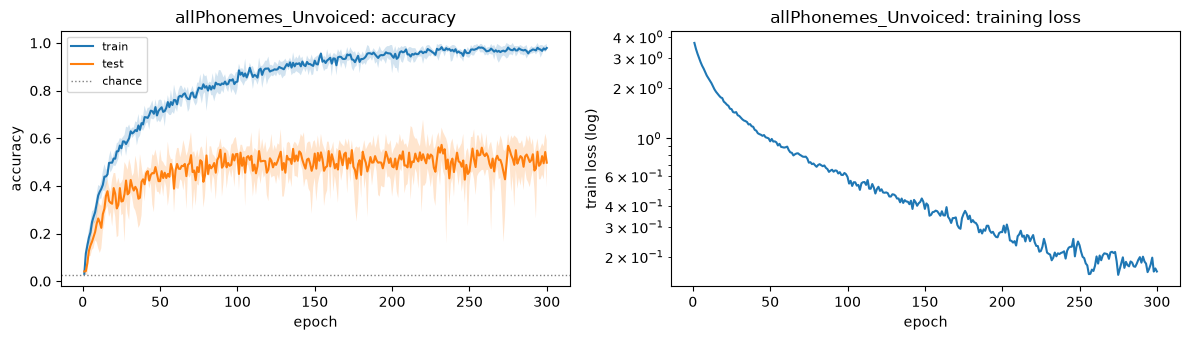

In [12]:
plotTrainingCurves("allPhonemes_Unvoiced")

## 3. All words, voiced

In [13]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Words", "Voiced")
trainAllSeeds("allWords_Voiced", trainTrials, trainLabels, testTrials, testLabels)

Subject 2 Words Voiced: train (216, 22, 7500), test (144, 22, 7500)
=== allWords_Voiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch


    10      2.1426      0.546     2.0535     0.472  1.0e-03     0.56


    20      1.3590      0.736     1.6496     0.521  1.0e-03     0.56


    30      0.8527      0.875     1.2118     0.646  1.0e-03     0.56


    40      0.5960      0.926     1.2004     0.611  1.0e-03     0.56


...

   260      0.0084      1.000     0.2897     0.903  1.0e-03     0.56


   270      0.0074      1.000     0.3041     0.924  1.0e-03     0.56


   280      0.0045      1.000     0.2624     0.917  1.0e-03     0.56


   290      0.0043      1.000     0.2051     0.951  1.0e-03     0.56


   300      0.0035      1.000     0.3145     0.896  1.0e-03     0.56
test accuracy, allWords_Voiced seed 4:
  at lowest train loss (ours)  0.924  (epoch 293)
  best across epochs (ours)    0.958  (epoch 291)
  final epoch                  0.896
  saved model from epoch 291 to results/allWords_Voiced_seed4_bestTestAccuracy.pt


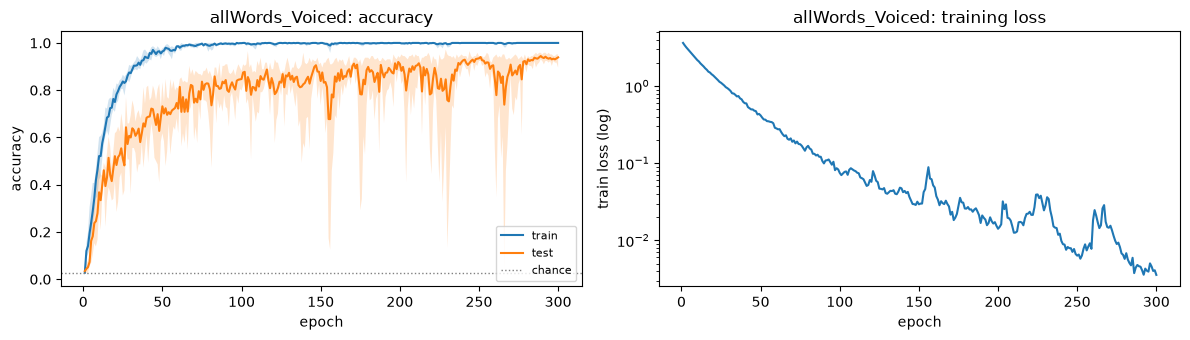

In [14]:
plotTrainingCurves("allWords_Voiced")

## 4. All words, unvoiced

In [15]:
trainTrials, trainLabels, testTrials, testLabels = loadTrialsOntoGpu("Words", "Unvoiced")
trainAllSeeds("allWords_Unvoiced", trainTrials, trainLabels, testTrials, testLabels)

Subject 2 Words Unvoiced: train (216, 22, 7500), test (144, 22, 7500)
=== allWords_Unvoiced, seed 0
 epoch  train loss  train acc  test loss  test acc       lr  s/epoch


    10      2.2956      0.532     2.2904     0.340  1.0e-03     0.56


    20      1.4185      0.727     1.9547     0.347  1.0e-03     0.56


    30      0.9208      0.866     1.3167     0.653  1.0e-03     0.56


    40      0.6362      0.907     1.5174     0.472  1.0e-03     0.56


...

   260      0.0070      1.000     0.5394     0.847  1.0e-03     0.59


   270      0.0279      0.995     1.3369     0.694  1.0e-03     0.59


   280      0.0141      1.000     0.8041     0.771  1.0e-03     0.59


   290      0.0082      1.000     0.5833     0.799  1.0e-03     0.59


   300      0.0529      0.995     1.3150     0.618  1.0e-03     0.59
test accuracy, allWords_Unvoiced seed 4:
  at lowest train loss (ours)  0.847  (epoch 258)
  best across epochs (ours)    0.875  (epoch 257)
  final epoch                  0.618
  saved model from epoch 257 to results/allWords_Unvoiced_seed4_bestTestAccuracy.pt


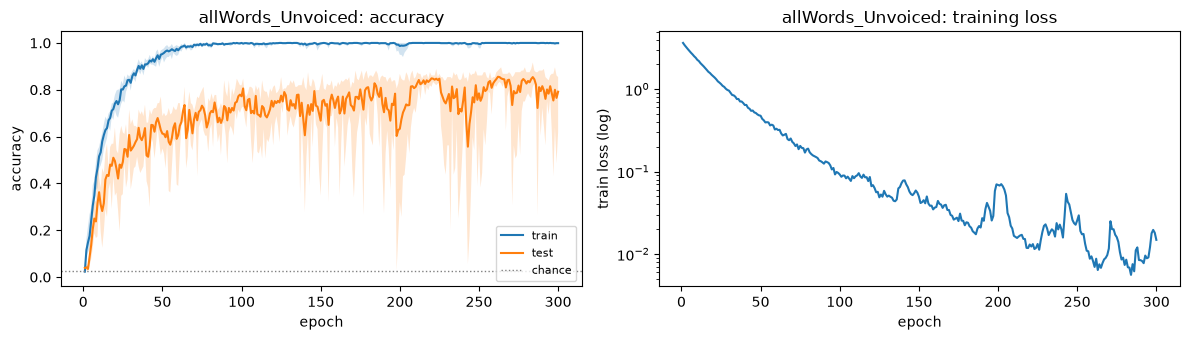

In [16]:
plotTrainingCurves("allWords_Unvoiced")

## Overall statistics

Our ResNet1D's test accuracy per config, at the lowest-training-loss epoch and at the best epoch (mean ± std over seeds; std is 0 with one seed), from everything in `results/results.json`, next to the paper's SPD-RNN result for the same subject and config (Gowda et al., Table 10 column A for phonemes, Table 11 for words; mean ± std over 10 seeds). The paper reports the best test accuracy across epochs, so compare it with the "best across epochs (ours)" column; the paper has no lowest-training-loss equivalent.

In [17]:
# Paper's SPD-RNN accuracy for Subject 2 (Gowda et al., Table 10 column A and Table 11): mean, std over 10 seeds.
paperSpdRnnAccuracies = {"allPhonemes_Voiced": (0.659, 0.023), "allPhonemes_Unvoiced": (0.59, 0.017),
                         "allWords_Voiced": (0.865, 0.013), "allWords_Unvoiced": (0.745, 0.025)}

print(f"{'config':<22} {'classes':>7} {'chance':>7} {'seeds':>5} {'epochs':>6}   "
      + f"{accuracyRuleLabels['testAccuracyAtLowestTrainLoss']:>27}   {accuracyRuleLabels['bestTestAccuracy']:>27}   {'SPD-RNN (paper)':>27}")

for configName, config in results.items():
    accuracyCells = []
    for ruleKey in ["testAccuracyAtLowestTrainLoss", "bestTestAccuracy"]:
        accuracies = np.array([run[ruleKey] for run in config["runs"]])
        accuracyCells.append(f"{accuracies.mean():.3f} ± {accuracies.std():.3f}")
    paperMean, paperStd = paperSpdRnnAccuracies[configName]
    accuracyCells.append(f"{paperMean:.3f} ± {paperStd:.3f}")

    print(f"{configName:<22} {config['numberClasses']:>7} {1 / config['numberClasses']:>7.3f} {config['numberSeeds']:>5} {config['numberEpochs']:>6}   "
          + "   ".join(f"{accuracyCell:>27}" for accuracyCell in accuracyCells))

config                 classes  chance seeds epochs   at lowest train loss (ours)     best across epochs (ours)               SPD-RNN (paper)
allPhonemes_Voiced          38   0.026     5    300                 0.605 ± 0.034                 0.699 ± 0.009                 0.659 ± 0.023
allPhonemes_Unvoiced        38   0.026     5    300                 0.537 ± 0.059                 0.642 ± 0.023                 0.590 ± 0.017
allWords_Voiced             36   0.028     5    300                 0.942 ± 0.014                 0.961 ± 0.007                 0.865 ± 0.013
allWords_Unvoiced           36   0.028     5    300                 0.854 ± 0.017                 0.885 ± 0.019                 0.745 ± 0.025


### Matched epoch budget: first 150 epochs

The paper's SPD-RNN notebooks train for 150 epochs, so its best-across-epochs number had 150 chances; ours had `numberEpochs`.
This recomputes our accuracies (at the lowest training loss, and the best) using only epochs 1–150 of each run's saved history (no retraining), for a same-rule, same-budget comparison.

In [18]:
paperEpochs = 150   # numberEpochs in allPhonemesRnn.ipynb / wordsRnn.ipynb

print(f"{'config':<22} {'seeds':>5}   {'lowest train loss, 1-150':>27}   {'best, epochs 1-150 (ours)':>27}   {'SPD-RNN (paper)':>27}")

for configName, config in results.items():
    testAccuraciesBySeed = [run["history"]["testAccuracy"][:paperEpochs] for run in config["runs"]]
    trainLossesBySeed = [run["history"]["trainLoss"][:paperEpochs] for run in config["runs"]]
    lowestTrainLossAccuracies = np.array([testAccuracies[int(np.argmin(trainLosses))]
                                          for testAccuracies, trainLosses in zip(testAccuraciesBySeed, trainLossesBySeed)])
    accuracies = np.array([max(testAccuracies) for testAccuracies in testAccuraciesBySeed])
    paperMean, paperStd = paperSpdRnnAccuracies[configName]

    print(f"{configName:<22} {config['numberSeeds']:>5}   {f'{lowestTrainLossAccuracies.mean():.3f} ± {lowestTrainLossAccuracies.std():.3f}':>27}"
          f"   {f'{accuracies.mean():.3f} ± {accuracies.std():.3f}':>27}   {f'{paperMean:.3f} ± {paperStd:.3f}':>27}")

config                 seeds      lowest train loss, 1-150     best, epochs 1-150 (ours)               SPD-RNN (paper)
allPhonemes_Voiced         5                 0.575 ± 0.037                 0.661 ± 0.016                 0.659 ± 0.023
allPhonemes_Unvoiced       5                 0.522 ± 0.033                 0.614 ± 0.022                 0.590 ± 0.017
allWords_Voiced            5                 0.908 ± 0.010                 0.936 ± 0.017                 0.865 ± 0.013
allWords_Unvoiced          5                 0.769 ± 0.046                 0.849 ± 0.015                 0.745 ± 0.025
